<a href="https://colab.research.google.com/github/MasaAsami/ml-dae/blob/main/notebooks/tree_based_DEA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tree-based DAE
- 普通のDEA、効率性分析はDMUそのものの効率性を調査する
- しかし、中には特定のinput(補助金や特定の費用)に着目して、各ユニットにおける当該inputの効率的使用に関心が向けられるケースもあるだろう（関心inputと呼ぶ）
- このとき、DEAのフレームワークをそのまま適用することは危険である。関心inputは、その他のinputと相関がある可能性がある。例えば、資本金に応じて補助金が配られている場合など
- 因果推論のターミノロジーを使えば、交絡である
- Athey & Inbens(2016)やWager, S. & Athey, S. (2018) を本研究では活用。特にPropensity treeを用いて、各Leaf内で共変量をバランス化し、各Leaf内でDEAを実施することを提案する
- 各Leaf内でinputとoutputについては、通常の効率性分析(DEAやSFAなど)を用いても構わない
- また、各leafはfoacal input以外のDMUの特徴量は類似しているため、適切なベンチマークを提示することができる


In [1]:
import warnings
warnings.simplefilter("ignore")
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('ggplot')
import itertools
import random
import pandas as pd
import numpy as np
import numpy.random as rand
from scipy import stats

In [2]:
SIZE = 400
np.random.seed(2025)

X = np.random.normal(loc=0, scale=3, size=(SIZE, 2))
#X = np.random.uniform(-2., 2, size=(SIZE, 2))
df = pd.DataFrame(X, columns=[f'input_{i+1}' for i in range(2)])
df["group_1"] = pd.qcut(df["input_1"],3, labels= [1, 2, 3]).astype(int)
df["group_2"] = pd.qcut(df["input_2"],2, labels= [1, 2]).astype(int)

df["group_prod"] = df["group_1"] + df["group_2"]


# 決定木のルールを作る
def generate_D(x):
    if x == 5:
        raw_d = np.random.normal(loc=6, scale=2)
    elif x == 4:
        raw_d = np.random.normal(loc=4, scale=1.5)
    elif x == 3:
        raw_d = np.random.normal(loc=3, scale=1.5)
    else:
        raw_d = np.random.normal(loc=0, scale=2)
    return raw_d

D = df["group_prod"].apply(generate_D)
df['target_input'] = D

other_input_cols = [_col for _col in df.columns if "input_" in _col]

df += 20
assert df.min().min() > 0


beta1_list = [-1.25, -0.75]
beta2_list = [-0.75, -1.25]

sim1_efficiency = np.random.normal(1., 0.05, SIZE)
sim2_efficiency = np.random.normal(1, 0.05, SIZE)


target1_effect = df["target_input"].values * sim1_efficiency
target2_effect = df["target_input"].values * sim2_efficiency

y1 = df[other_input_cols].values @ beta1_list + target1_effect + 50 + np.random.normal(0, 1, SIZE)
y2 = df[other_input_cols].values @ beta2_list + target2_effect + 50 + np.random.normal(0, 1, SIZE)

df["output_1"] = y1
df["output_2"] = y2
assert df.min().min() > 0


# 実験用サブメトリクス
# Ground Truth
df["graund_truth_efficiency1"] = sim1_efficiency
df["graund_truth_efficiency2"] = sim2_efficiency

# 費用vs.outcome ratio
df["retio_1"] = df["output_1"] / df["target_input"]
df["retio_2"] = df["output_2"] / df["target_input"]

df = df.drop(columns=["group_1", "group_2"])

In [3]:
df.min()

,0
input_1,10.448809
input_2,12.435143
group_prod,22.000000
target_input,14.917619
output_1,21.547936
output_2,19.918908
graund_truth_efficiency1,0.843715
graund_truth_efficiency2,0.834149
retio_1,0.919312
retio_2,0.849812


In [4]:
df.sample(3)

,input_1,input_2,group_prod,target_input,output_1,output_2,graund_truth_efficiency1,graund_truth_efficiency2,retio_1,retio_2
87,20.608809,22.309359,24,23.631886,34.794568,28.630365,1.011319,0.917680,1.472357,1.211514
206,21.462359,19.188774,24,22.583525,31.275978,29.549878,0.954656,0.921750,1.384902,1.308471
173,17.724191,19.789638,23,21.560605,35.908016,31.927773,1.054846,1.009609,1.665446,1.480839


In [5]:
def linear_regression(d, outcome="output_1"):
    return stats.linregress(d["target_input"], d[outcome])

original_result_1 = linear_regression(df, outcome="output_1")
original_result_2 = linear_regression(df, outcome="output_2")

print(f"vs.outcome 1 coef {original_result_1.slope:.3f} p-value {original_result_1.pvalue:.3f}")
print(f"vs.outcome 2 coef {original_result_2.slope:.3f} p-value {original_result_2.pvalue:.3f}")

vs.outcome 1 coef -0.052 p-value 0.496
vs.outcome 2 coef 0.076 p-value 0.345


In [6]:
# fig, ax = plt.subplots(1, 2, figsize=(15, 5), dpi=300)

# sns.scatterplot(
#     data=df,
#     x="target_input",
#     y="output_1",
#     alpha = .5,
#     ax=ax[0],
#     color="black"
# )
# sns.scatterplot(
#     data=df,
#     x="target_input",
#     y="output_2",
#     alpha = .5,
#     ax=ax[1],
#     color="black"
# )

# # ax[0].set_xlabel(r"Forcal input
# # ")
# # ax[0].set_ylabel(r"Output 1
# # ")
# # ax[1].set_xlabel(r"Forcal input
# # ")
# # ax[1].set_ylabel(r"Output 2
# # ")

# plt.show()

In [7]:
df.corr(method="spearman")

,input_1,input_2,group_prod,target_input,output_1,output_2,graund_truth_efficiency1,graund_truth_efficiency2,retio_1,retio_2
input_1,1.000000,-0.039303,0.805357,0.501589,-0.609313,-0.196675,-0.047155,-0.026827,-0.797642,-0.497747
input_2,-0.039303,1.000000,0.414938,0.367726,-0.284038,-0.627195,0.046733,-0.036724,-0.439102,-0.751596
group_prod,0.805357,0.414938,1.000000,0.666367,-0.540996,-0.340316,-0.035330,-0.025306,-0.865185,-0.744577
target_input,0.501589,0.367726,0.666367,1.000000,-0.030499,0.046285,0.006537,0.044615,-0.666902,-0.638473
output_1,-0.609313,-0.284038,-0.540996,-0.030499,1.000000,0.668510,0.300941,0.100101,0.724393,0.517203
output_2,-0.196675,-0.627195,-0.340316,0.046285,0.668510,1.000000,-0.012290,0.371075,0.427666,0.688101
graund_truth_efficiency1,-0.047155,0.046733,-0.035330,0.006537,0.300941,-0.012290,1.000000,0.020392,0.227324,0.000644
graund_truth_efficiency2,-0.026827,-0.036724,-0.025306,0.044615,0.100101,0.371075,0.020392,1.000000,0.027624,0.237247
retio_1,-0.797642,-0.439102,-0.865185,-0.666902,0.724393,0.427666,0.227324,0.027624,1.000000,0.810319
retio_2,-0.497747,-0.751596,-0.744577,-0.638473,0.517203,0.688101,0.000644,0.237247,0.810319,1.000000


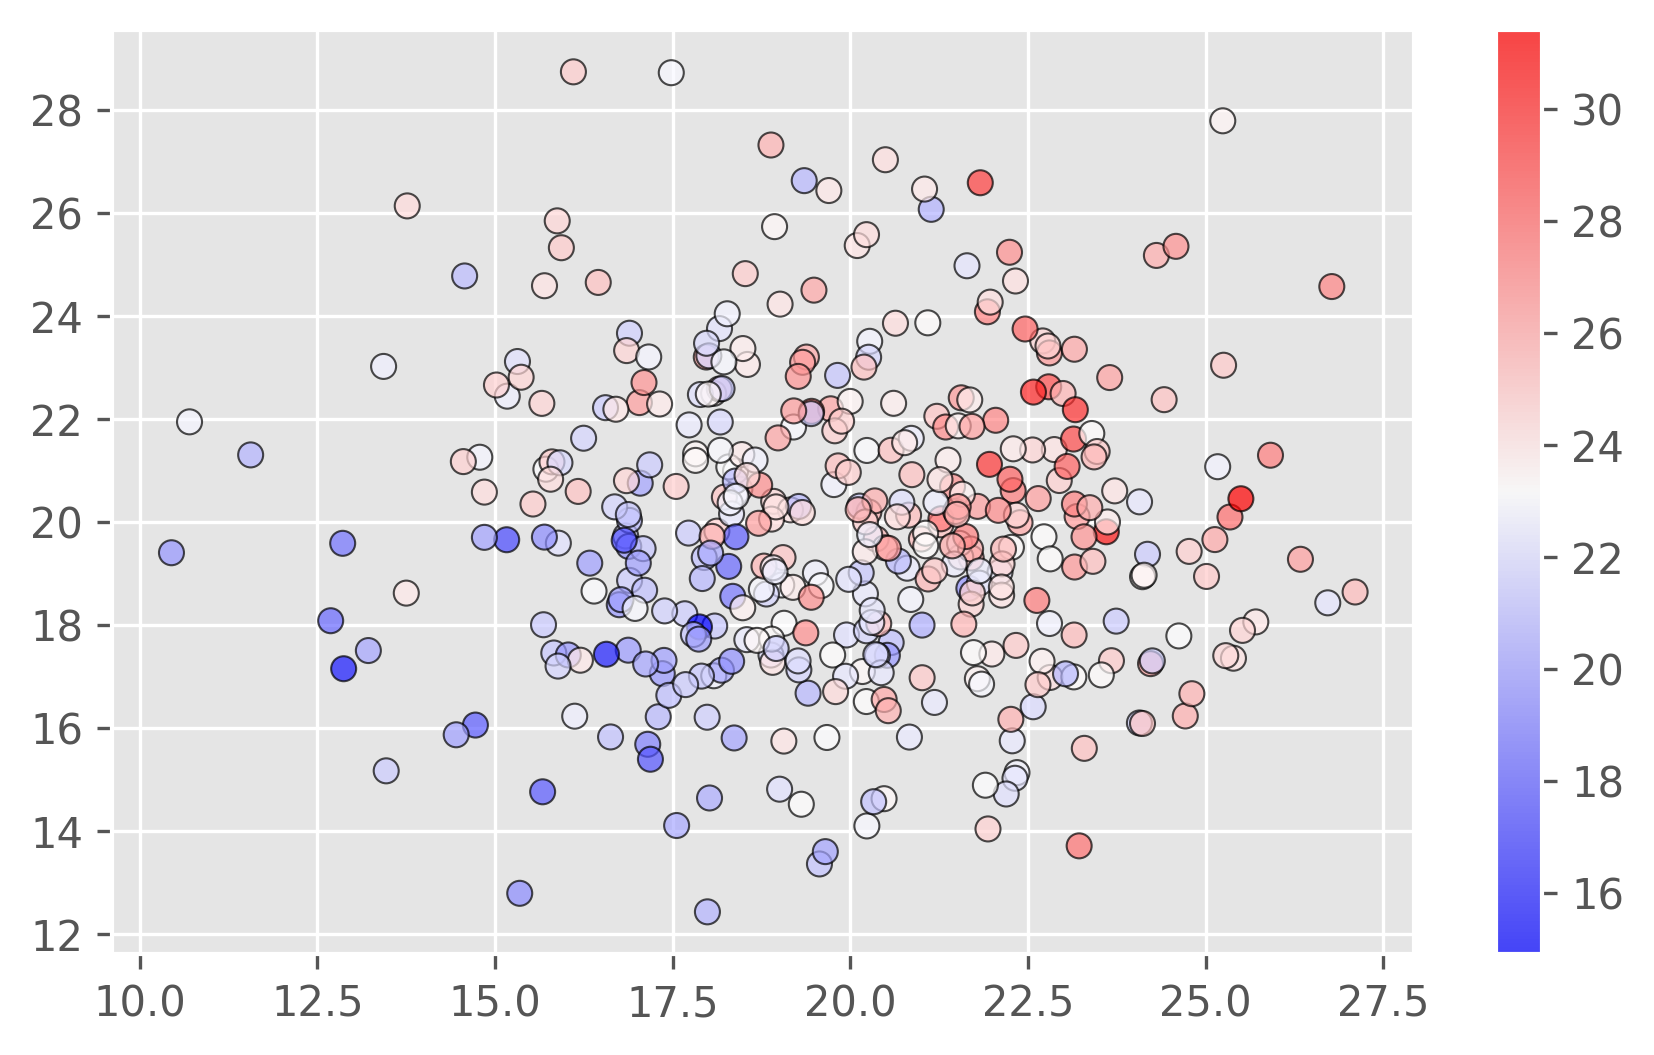

In [8]:
fig = plt.figure(figsize=(7, 4), dpi=300)

plt.scatter(
    data=df,
    x="input_1",
    y="input_2",
    alpha =0.7,
    c = df["target_input"],
    cmap = 'bwr',
    edgecolors="black",

)
cbar = plt.colorbar()

plt.show()

In [9]:
# split into train and test sample
from sklearn.model_selection import train_test_split
df1, df2 = train_test_split(df,train_size=0.5,random_state=2025)

In [10]:
# select model
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
dtr1=DecisionTreeRegressor(max_depth=3, random_state=2025, min_samples_leaf=30) # , min_samples_leaf=30
dtr2=DecisionTreeRegressor(max_depth=3, random_state=2025, min_samples_leaf=30)

In [11]:
dtr1.fit(df1[other_input_cols],df1["target_input"])
dtr2.fit(df2[other_input_cols],df2["target_input"])

DecisionTreeRegressor(max_depth=3, min_samples_leaf=30, random_state=2025)

In [12]:
# tree.plot_tree(dtr1, proportion=True)
# plt.show()

In [13]:
# tree.plot_tree(dtr2, proportion=True)
# plt.show()

In [14]:
df_tree = pd.concat(
    [
        df2.assign(
            leaf_id = [f"tree1_{_id}" for _id in dtr1.apply(df2[other_input_cols])],
            pred_d = dtr1.predict(df2[other_input_cols]),
            model_id = 1
        ),
        df1.assign(
            leaf_id = [f"tree2_{_id}" for _id in dtr2.apply(df1[other_input_cols])],
            pred_d = dtr2.predict(df1[other_input_cols]),
            model_id = 2
        )
    ]
)
# df_tree = pd.concat(
#     [
#         df2.assign(
#             leaf_id = [f"tree1_{_id}" for _id in dtr2.apply(df2[other_input_cols])],
#             pred_d = dtr2.predict(df2[other_input_cols])
#         ),
#         df1.assign(
#             leaf_id = [f"tree2_{_id}" for _id in dtr1.apply(df1[other_input_cols])],
#             pred_d = dtr1.predict(df1[other_input_cols])
#         )
#     ]
# )

In [15]:
count_check = df_tree.groupby(["leaf_id"])[["target_input"]].count()#.query("target_input > 10")
count_check

,target_input
leaf_id,
tree1_10,39
tree1_2,26
tree1_3,36
tree1_6,24
tree1_7,43
tree1_9,32
tree2_2,38
tree2_3,30
tree2_5,54


In [16]:
leaf_id_list = count_check.index.tolist()
df_tree = df_tree.query("leaf_id in @leaf_id_list")

In [17]:
slope_result = pd.concat(
    [
        df_tree.groupby("leaf_id")["target_input"].count(),
        df_tree.groupby("leaf_id").apply(lambda x: linear_regression(x, outcome="output_1").slope),
        df_tree.groupby("leaf_id").apply(lambda x: linear_regression(x, outcome="output_2").slope),
        df_tree.groupby("leaf_id").apply(lambda x: linear_regression(x, outcome="output_1").pvalue),
        df_tree.groupby("leaf_id").apply(lambda x: linear_regression(x, outcome="output_2").pvalue),
        df_tree.groupby("leaf_id").apply(lambda x: linear_regression(x, outcome="output_1").stderr),
        df_tree.groupby("leaf_id").apply(lambda x: linear_regression(x, outcome="output_2").stderr)
    ],
    axis=1
)
slope_result.columns=["cnt", "output_1_slope", "output_2_slope", "output_1_pvalue", "output_2_pvalue", "output_1_stderr", "output_2_stderr"]
slope_result.style.bar(color='#ff781c', vmin=0.0, vmax=1.0, subset=["output_1_pvalue", "output_2_pvalue"])

,cnt,output_1_slope,output_2_slope,output_1_pvalue,output_2_pvalue,output_1_stderr,output_2_stderr
leaf_id,,,,,,,
tree1_10,39,0.962753,1.097727,0.000003,0.000005,0.176440,0.206536
tree1_2,26,0.292259,0.710398,0.467415,0.056751,0.395785,0.354907
tree1_3,36,0.443277,0.525666,0.087457,0.050915,0.251907,0.259752
tree1_6,24,0.795721,1.229012,0.013258,0.007859,0.295378,0.420312
tree1_7,43,1.141701,0.905317,0.000002,0.000580,0.207924,0.242681
tree1_9,32,0.720635,0.285284,0.059014,0.390327,0.367166,0.327295
tree2_2,38,0.873893,0.988743,0.000084,0.000270,0.197269,0.244894
tree2_3,30,1.170838,1.196396,0.034372,0.039263,0.526403,0.553218
tree2_5,54,0.764703,0.859618,0.003845,0.000573,0.252696,0.234255


In [18]:
# error_corr_result = pd.concat(
#     [
#         df_tree.groupby("leaf_id").apply(lambda x: x[["target_input", "output_1"]].corr(method="spearman").values[0][1]),
#         df_tree.groupby("leaf_id").apply(lambda x: x[["target_input", "output_2"]].corr(method="spearman").values[0][1])
#     ]
#     ,axis=1
# )

# error_corr_result.columns=["output_1_corr", "output_2_corr"]
# error_corr_result.style.bar(color='#ff781c', vmin=0.0, vmax=1.0)

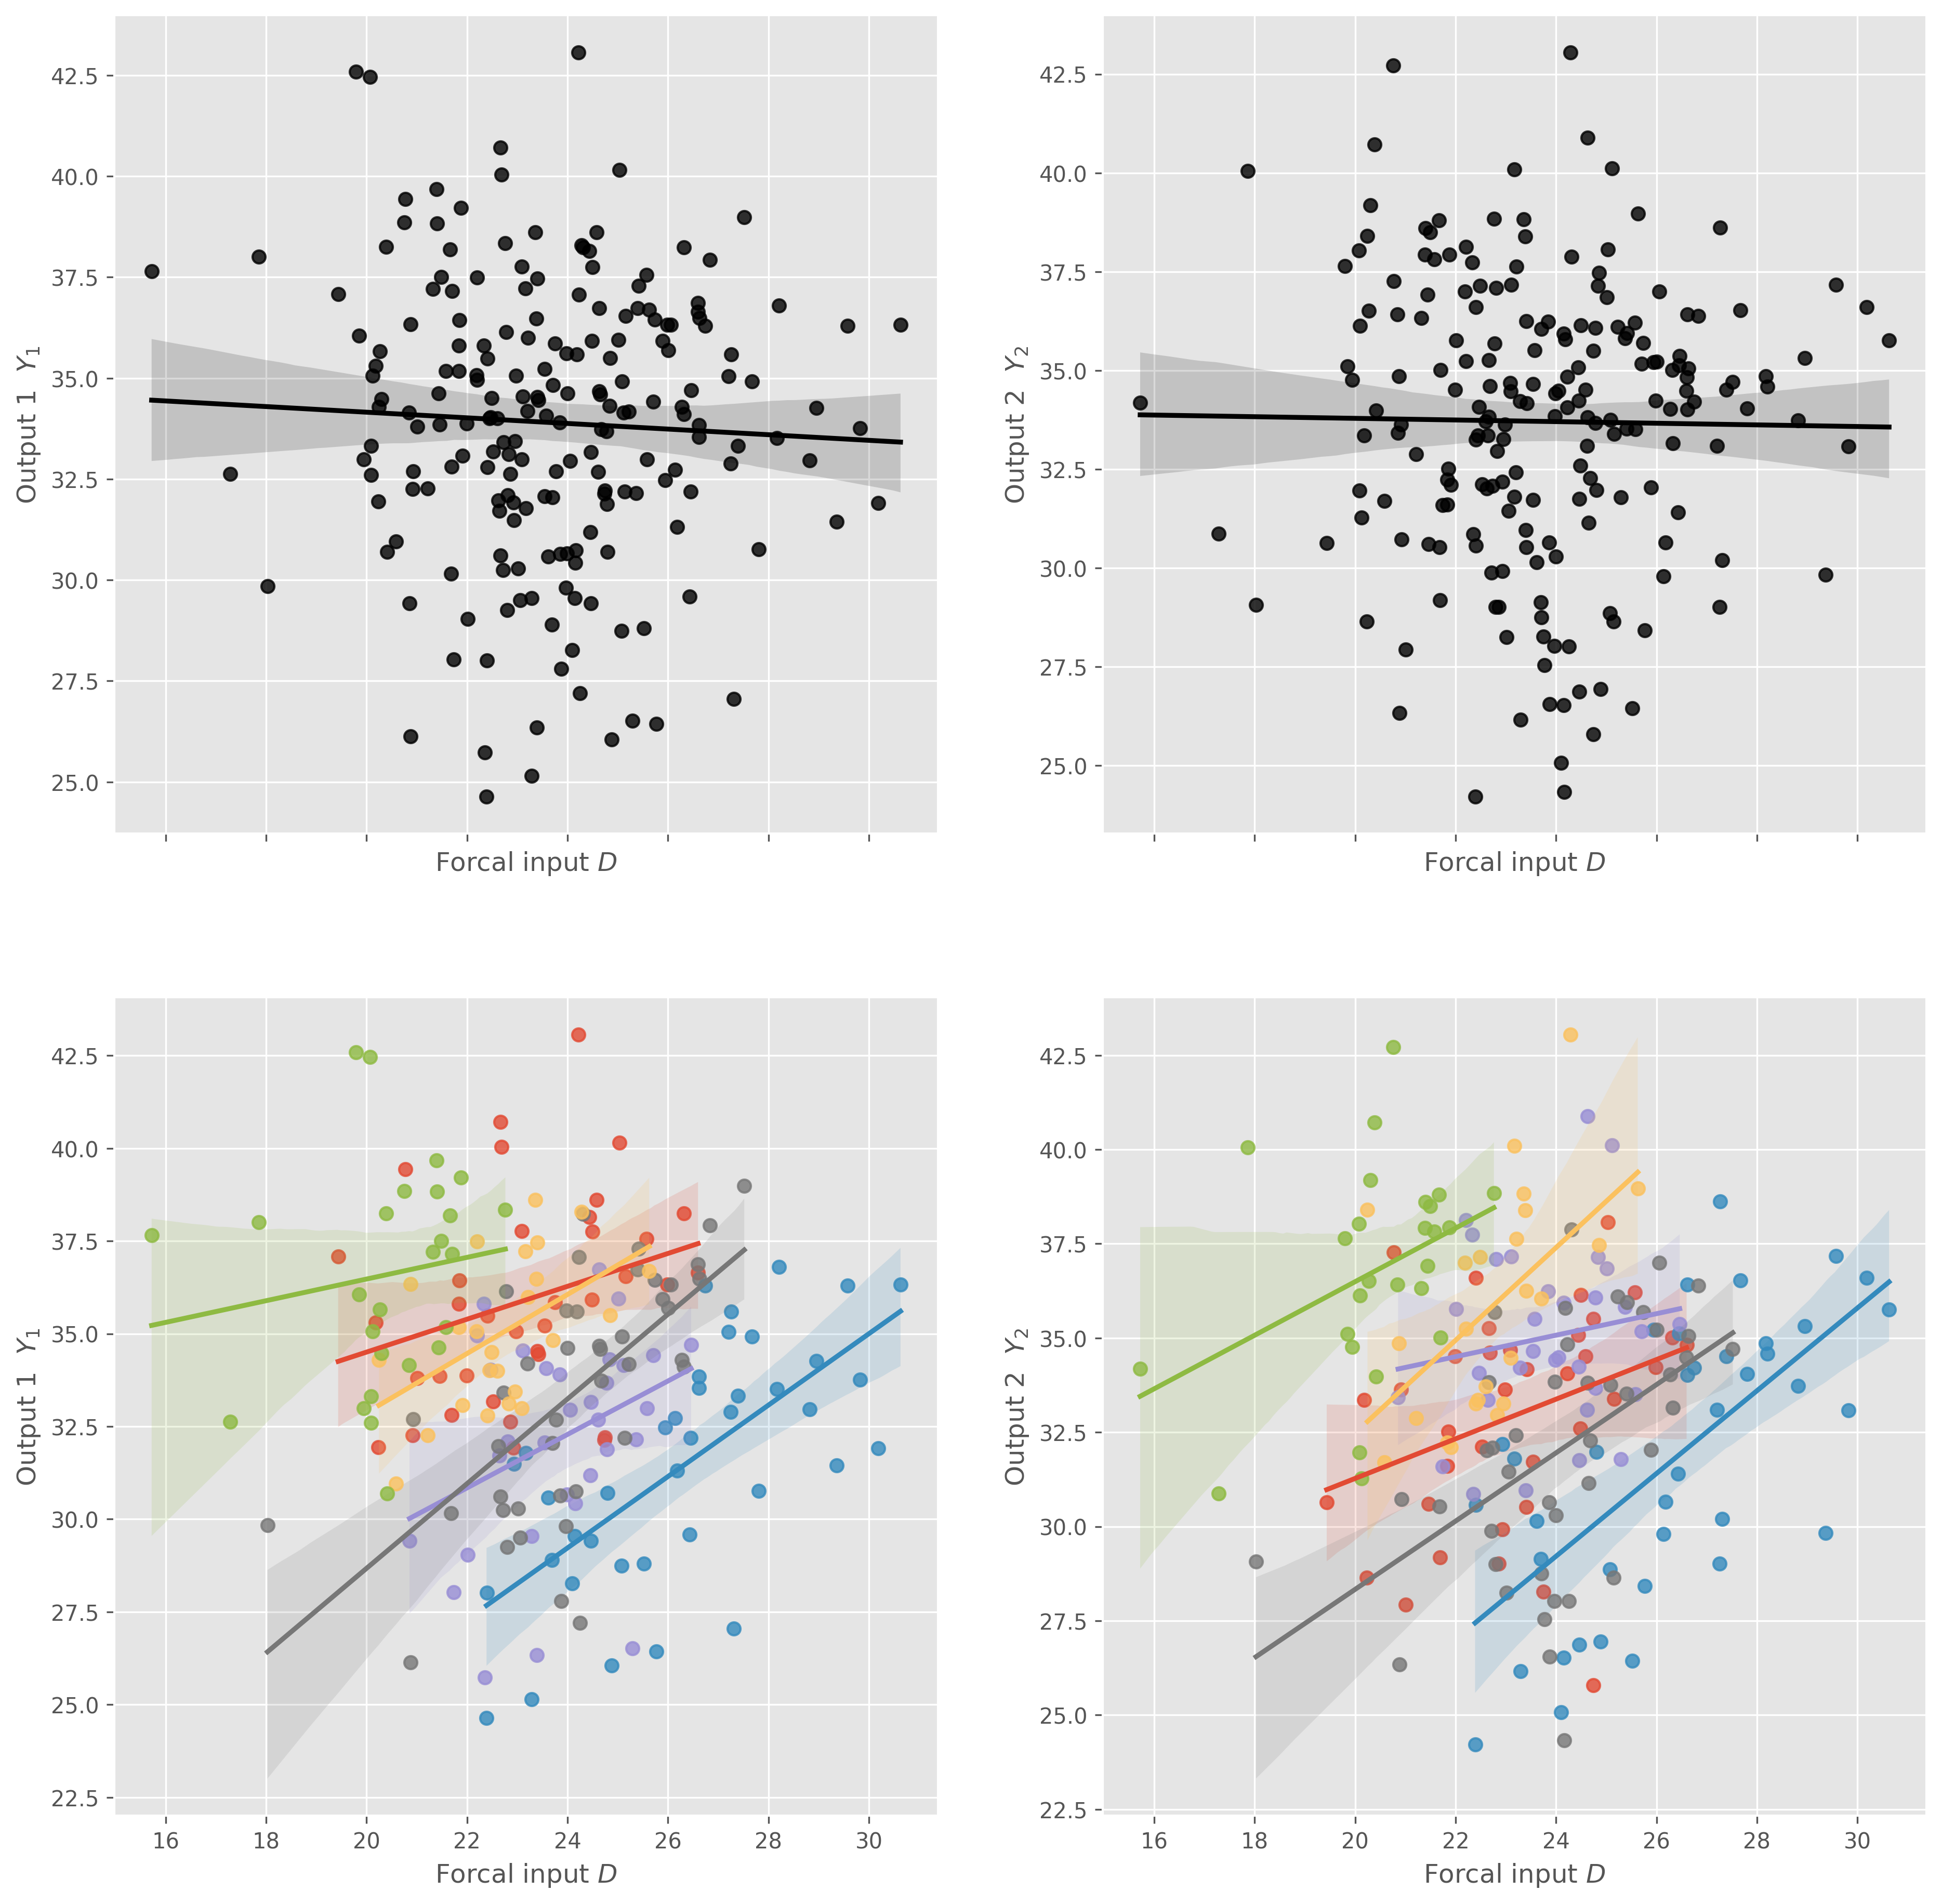

In [19]:
model_1_leaf_list = df_tree.query("model_id == 1")["leaf_id"].unique().tolist()

current_palette = sns.color_palette(n_colors=len(model_1_leaf_list))

fig, ax = plt.subplots(2, 2, figsize=(15, 15), dpi=300, sharex=True)

sns.regplot(df_tree.query("model_id == 1"), x="target_input", y="output_1", color="black", ax=ax[0][0])
sns.regplot(df_tree.query("model_id == 1"), x="target_input", y="output_2", color="black", ax=ax[0][1])

for i, _id in enumerate(model_1_leaf_list):
    sns.regplot(df_tree.query("model_id == 1 and leaf_id == @_id"), x="target_input", y="output_1", color=current_palette[i], ax=ax[1][0], label=f"leaf node {i}")
    sns.regplot(df_tree.query("model_id == 1 and leaf_id == @_id"), x="target_input", y="output_2", color=current_palette[i], ax=ax[1][1], label=f"leaf node {i}")

ax[0][0].set_xlabel(r"Forcal input $D$")
ax[0][1].set_xlabel(r"Forcal input $D$")
ax[1][0].set_xlabel(r"Forcal input $D$")
ax[1][1].set_xlabel(r"Forcal input $D$")
ax[0][0].set_ylabel(r"Output 1  $Y_1$")
ax[0][1].set_ylabel(r"Output 2  $Y_2$")
ax[1][0].set_ylabel(r"Output 1  $Y_1$")
ax[1][1].set_ylabel(r"Output 2  $Y_2$")
plt.show()

In [20]:
import numpy as np
from scipy.optimize import fmin_slsqp
from multiprocessing import Pool
from tqdm import tqdm

def optimize_one_unit(args):
    inputs, outputs, unit, m, r, n = args

    def target(x):
        in_w, out_w, lambdas = x[:m], x[m:m + r], x[m + r:]
        denominator = np.dot(inputs[unit], in_w)
        numerator = np.dot(outputs[unit], out_w)
        return numerator / denominator

    def constraints(x):
        in_w, out_w, lambdas = x[:m], x[m:m + r], x[m + r:]
        t = target(x)
        constr = []

        for i in range(m):
            lhs = np.dot(inputs[:, i], lambdas)
            constr.append(t * inputs[unit, i] - lhs)

        for o in range(r):
            lhs = np.dot(outputs[:, o], lambdas)
            constr.append(lhs - outputs[unit, o])

        for u in range(n):
            constr.append(lambdas[u])

        return np.array(constr)

    d0 = m + r + n
    x0 = np.random.rand(d0) - 0.5
    result = fmin_slsqp(target, x0, f_ieqcons=constraints, disp=False)
    in_w, out_w = result[:m], result[m:m + r]
    denominator = np.dot(inputs, in_w)
    numerator = np.dot(outputs, out_w)
    return (numerator / denominator)[unit]


class DEA(object):

    def __init__(self, inputs, outputs):
        self.inputs = inputs
        self.outputs = outputs

        self.n = inputs.shape[0]
        self.m = inputs.shape[1]
        self.r = outputs.shape[1]

        self.unit_ = range(self.n)
        self.input_ = range(self.m)
        self.output_ = range(self.r)

        self.output_w = np.zeros((self.r, 1), dtype=float)
        self.input_w = np.zeros((self.m, 1), dtype=float)
        self.lambdas = np.zeros((self.n, 1), dtype=float)
        self.efficiency = np.zeros_like(self.lambdas)

        self.names = []

    def __optimize(self):
        args = [(self.inputs, self.outputs, unit, self.m, self.r, self.n) for unit in self.unit_]
        with Pool() as pool:
            results = list(tqdm(pool.imap(optimize_one_unit, args), total=self.n, desc="Optimizing DEA"))
        self.efficiency = np.array(results).reshape(-1, 1)

    def name_units(self, names):
        assert self.n == len(names)
        self.names = names

    def fit(self):
        self.__optimize()



In [21]:
def sim_dea(df_tree, leaf_id, target_input="target_input", output_list=["output_1", "output_2"], efficiency_label="dea_efficiency"):
    dea_df = df_tree.query(f"leaf_id == @leaf_id")
    dea = DEA(
        dea_df[[target_input]].to_numpy(),
        dea_df[output_list].to_numpy()
    )
    dea.name_units(list(dea_df.index))
    dea.fit()
    dea_df[efficiency_label] = dea.efficiency
    return dea_df

In [22]:
efficiency_df_list = []
for _id in leaf_id_list:
    efficiency_df_list.append(
        sim_dea(df_tree, _id)
    )
efficiency_df = pd.concat(efficiency_df_list)

Optimizing DEA: 100%|██████████| 32/32 [00:00<00:00, 43.72it/s]


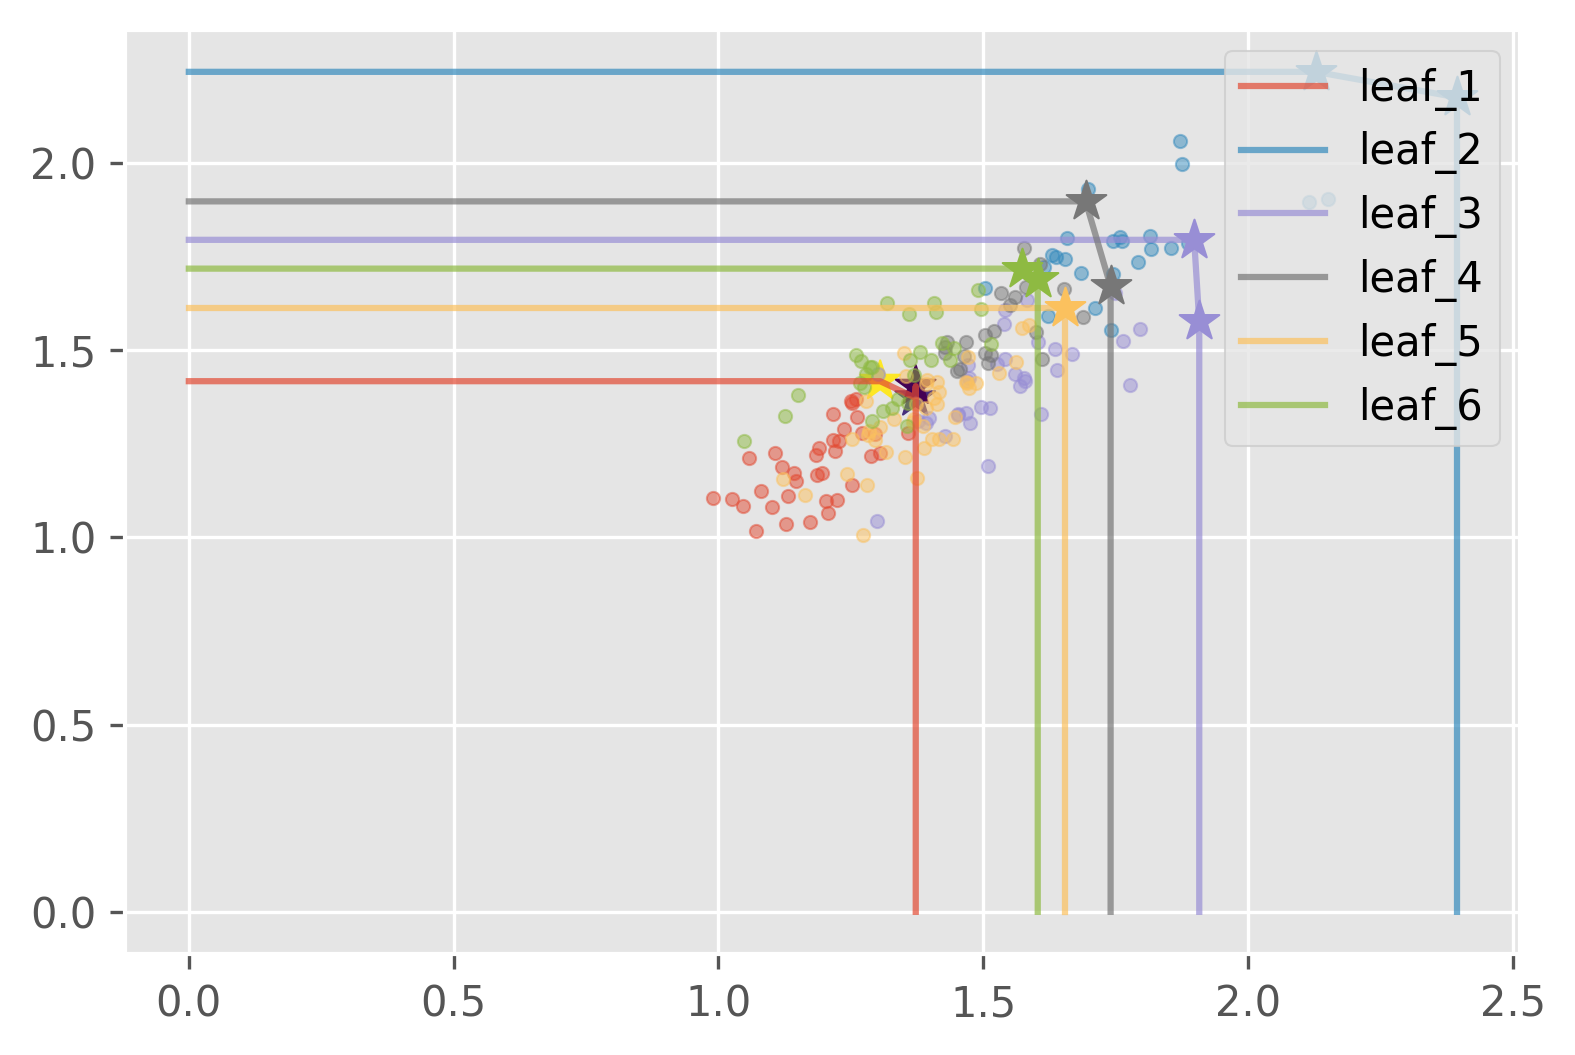

In [23]:
tree_1_id_list =[_id for _id in leaf_id_list if "tree1" in _id]
current_palette = sns.color_palette(n_colors=len(tree_1_id_list))
fig = plt.figure(figsize=(6, 4), dpi=300)

for i, _id in enumerate(tree_1_id_list):
    leaf_name = f"leaf_{i+1}"
    dea_df = efficiency_df.query("leaf_id == @_id")
    subset_efficent = dea_df.query("dea_efficiency > 0.99").sort_values("retio_1", ascending=True)

    fill_x = [0] + subset_efficent["retio_1"].to_list() + [subset_efficent.iloc[-1]["retio_1"]]
    fill_y = [subset_efficent.iloc[0]["retio_2"]] + subset_efficent["retio_2"].to_list() + [0]


    plt.plot(fill_x, fill_y, alpha=.7, color=current_palette[i], label=leaf_name)
    plt.scatter(
        subset_efficent.retio_1,
        subset_efficent.retio_2,
        s=100,
        alpha = 1,
        marker="*",
        c=current_palette[i],
    )
    plt.scatter(
        dea_df.query("dea_efficiency < 0.99").retio_1,
        dea_df.query("dea_efficiency < 0.99").retio_2,
        alpha = .5,
        s=10,
        c=current_palette[i],
        #edgecolors="black",
    )
plt.legend(loc = "upper right")
plt.xlabel(r"")
plt.ylabel(r"")
plt.grid(True)
# plt.xlim(0, 1.4)
# plt.ylim(0, 1.4)
plt.show()

In [24]:
leaf_id_list

['tree1_10',
 'tree1_2',
 'tree1_3',
 'tree1_6',
 'tree1_7',
 'tree1_9',
 'tree2_2',
 'tree2_3',
 'tree2_5',
 'tree2_7',
 'tree2_8']

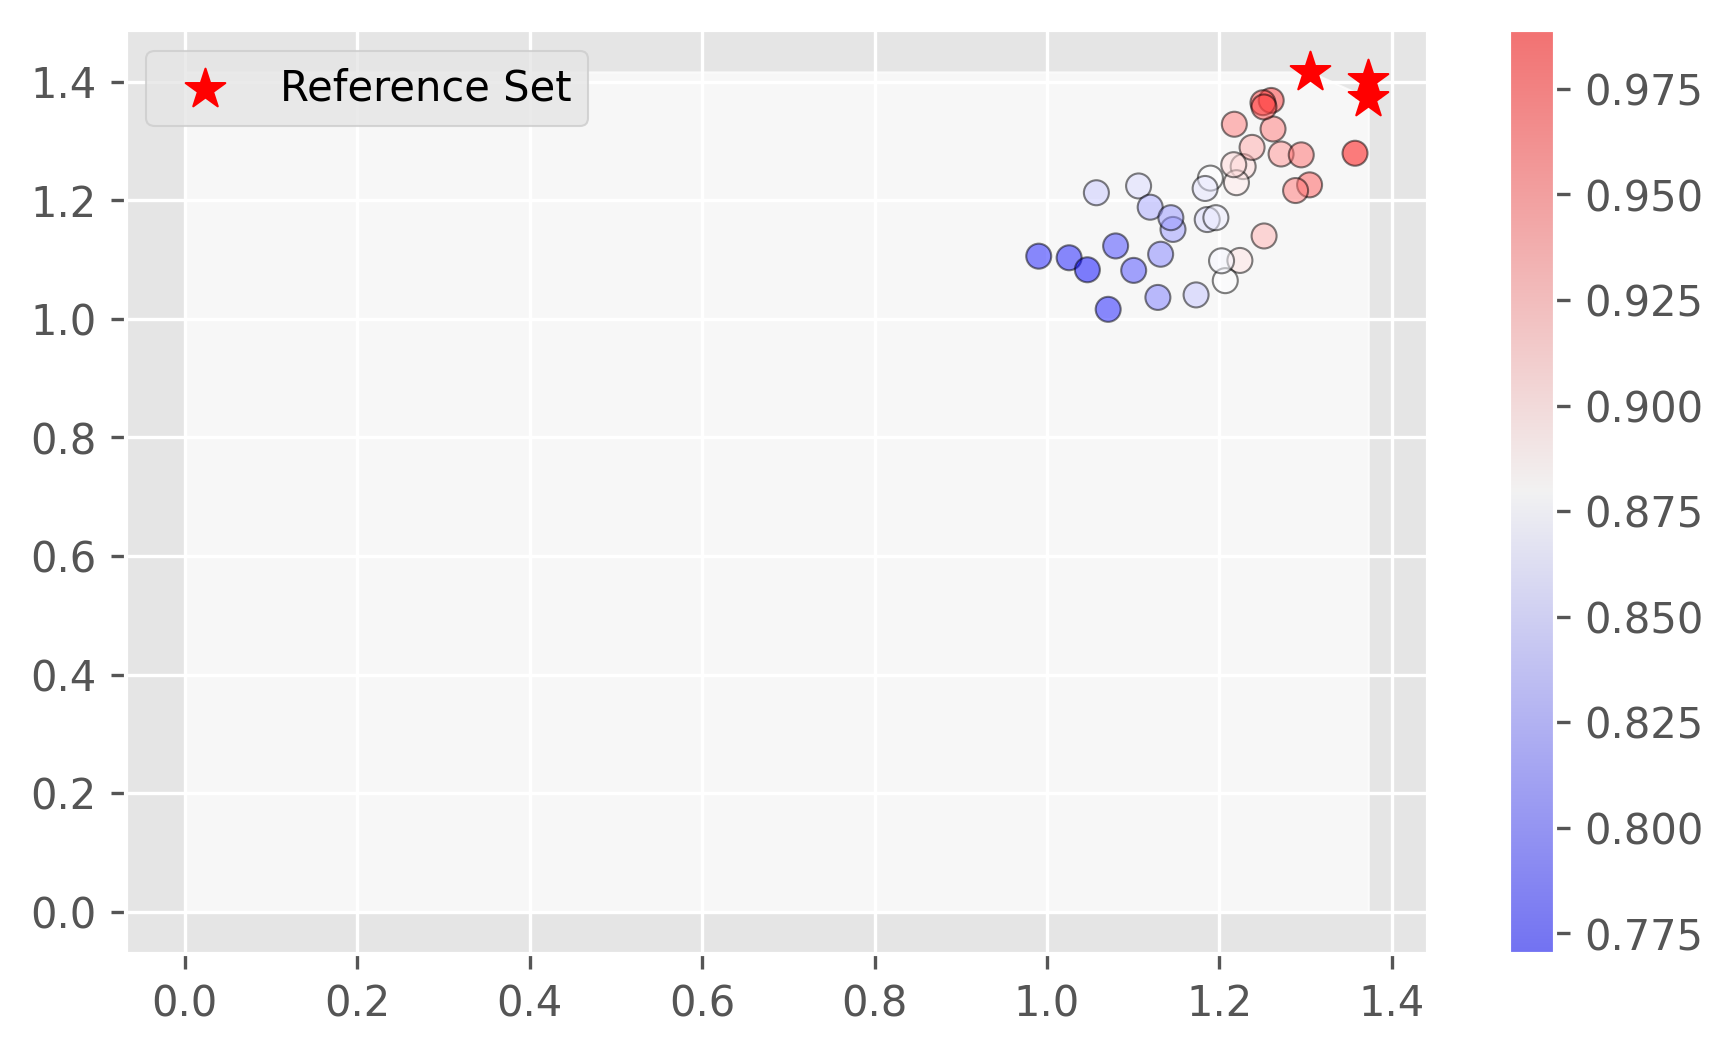

In [25]:
_id = leaf_id_list[0]
dea_df = efficiency_df.query("leaf_id == @_id")
subset_efficent = dea_df.query("dea_efficiency > 0.99").sort_values("retio_1", ascending=True)
fill_x = [0] + subset_efficent["retio_1"].to_list()
fill_y = [subset_efficent.iloc[0]["retio_2"]] + subset_efficent["retio_2"].to_list()

fig = plt.figure(figsize=(7, 4), dpi=300)
plt.fill_between(fill_x, 0, fill_y, color='w', alpha=.7)
plt.scatter(
    subset_efficent.retio_1,
    subset_efficent.retio_2,
    s=100,
    alpha = 1,
    marker="*",
    c="r",
    label='Reference Set'
)

plt.scatter(
    dea_df.query("dea_efficiency < 0.99").retio_1,
    dea_df.query("dea_efficiency < 0.99").retio_2,
    alpha = .5,
    c = dea_df.query("dea_efficiency < 0.99").dea_efficiency,
    cmap = 'bwr',
    edgecolors="black",
)
cbar = plt.colorbar()


plt.xlabel(r"")
plt.ylabel(r"")
plt.grid(True)
# plt.xlim(0, 1.4)
# plt.ylim(0, 1.4)
plt.legend(loc = "upper left")
plt.show()

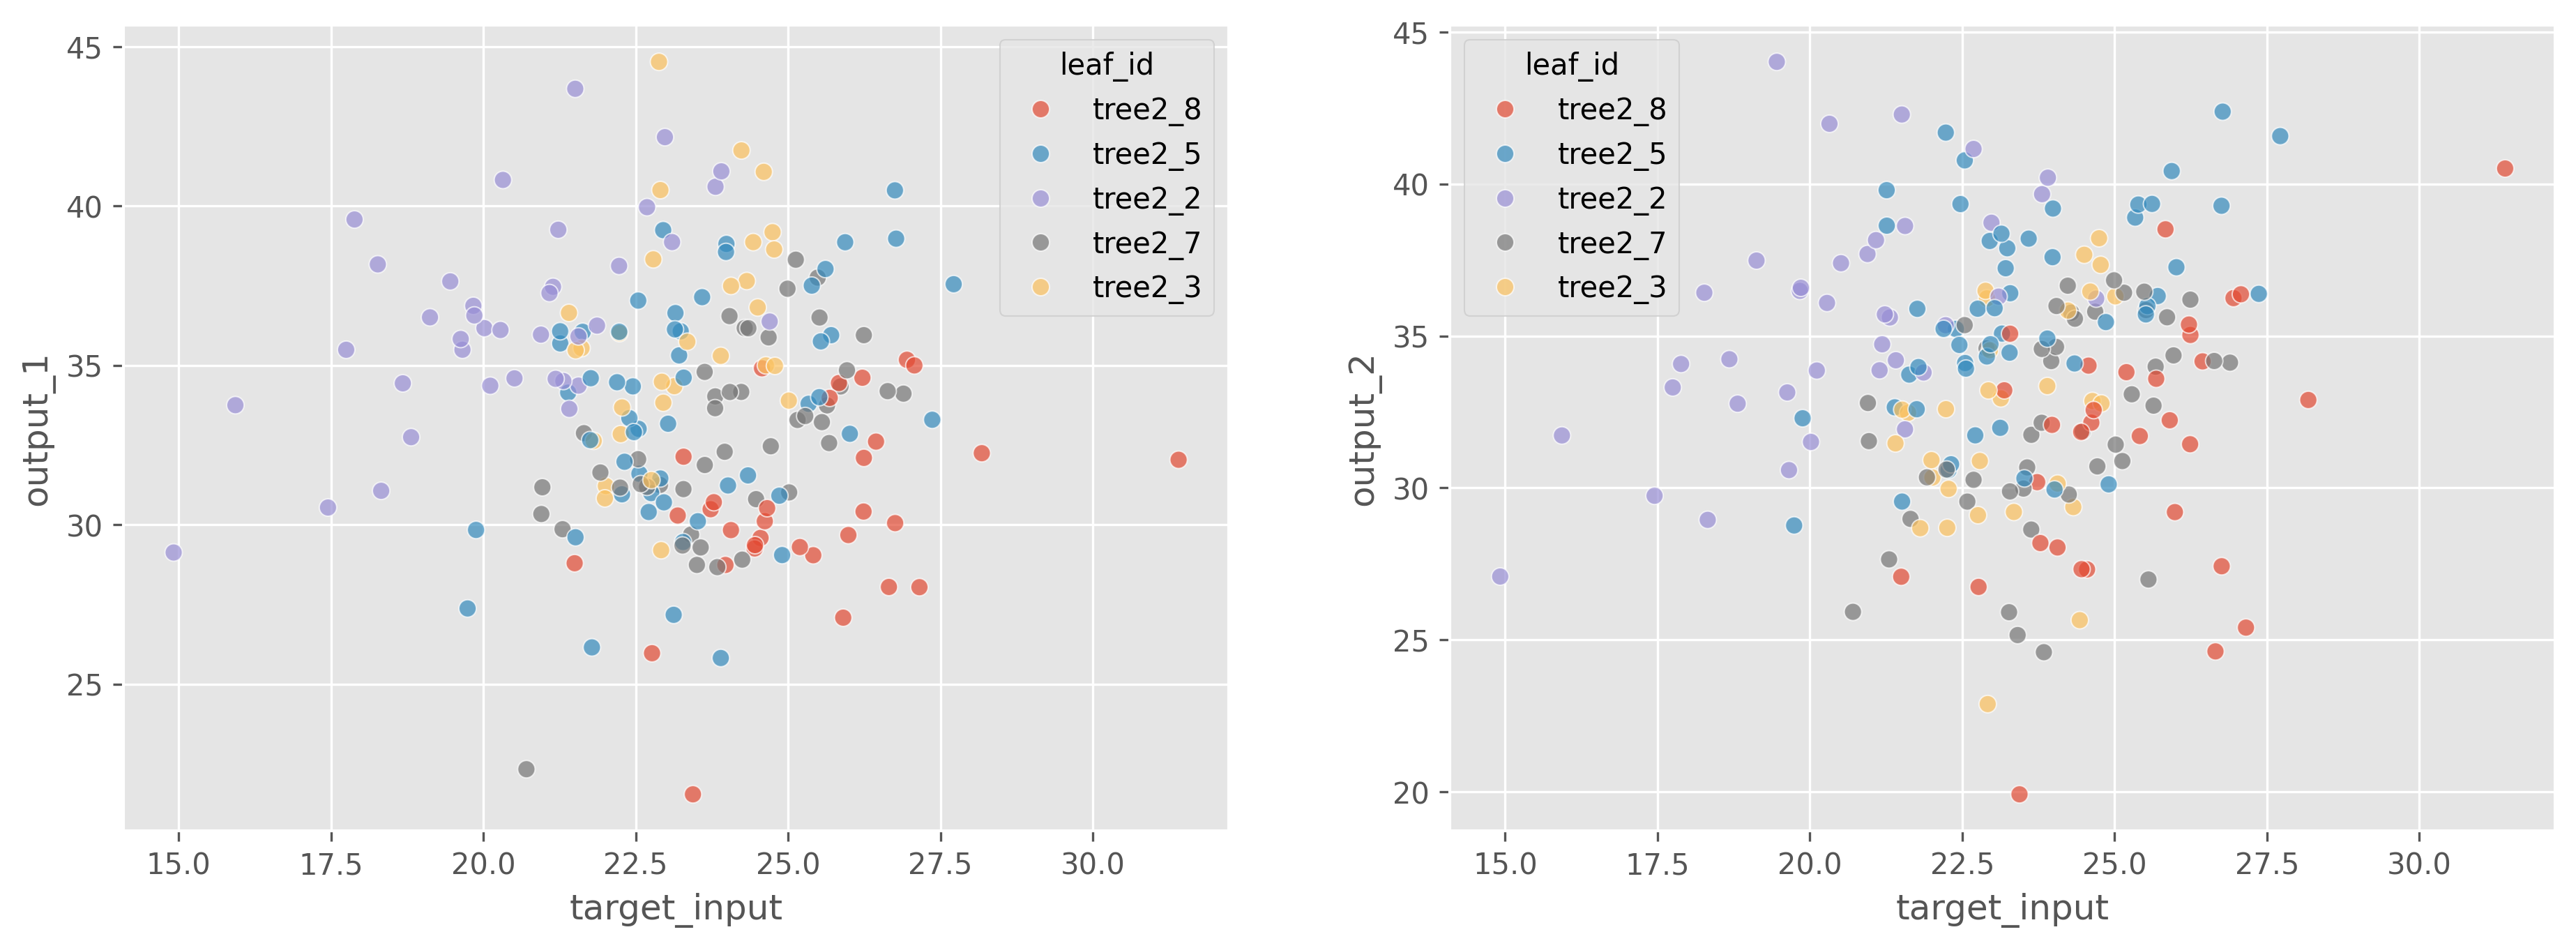

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5), dpi=300)

sns.scatterplot(
    data=df_tree.query("model_id == 2"),
    x="target_input",
    y="output_1",
    alpha =0.7,
    ax=ax[0],
    hue="leaf_id",
)

sns.scatterplot(
    data=df_tree.query("model_id == 2"),
    x="target_input",
    y="output_2",
    alpha =0.7,
    ax=ax[1],
    hue="leaf_id",
)
plt.show()

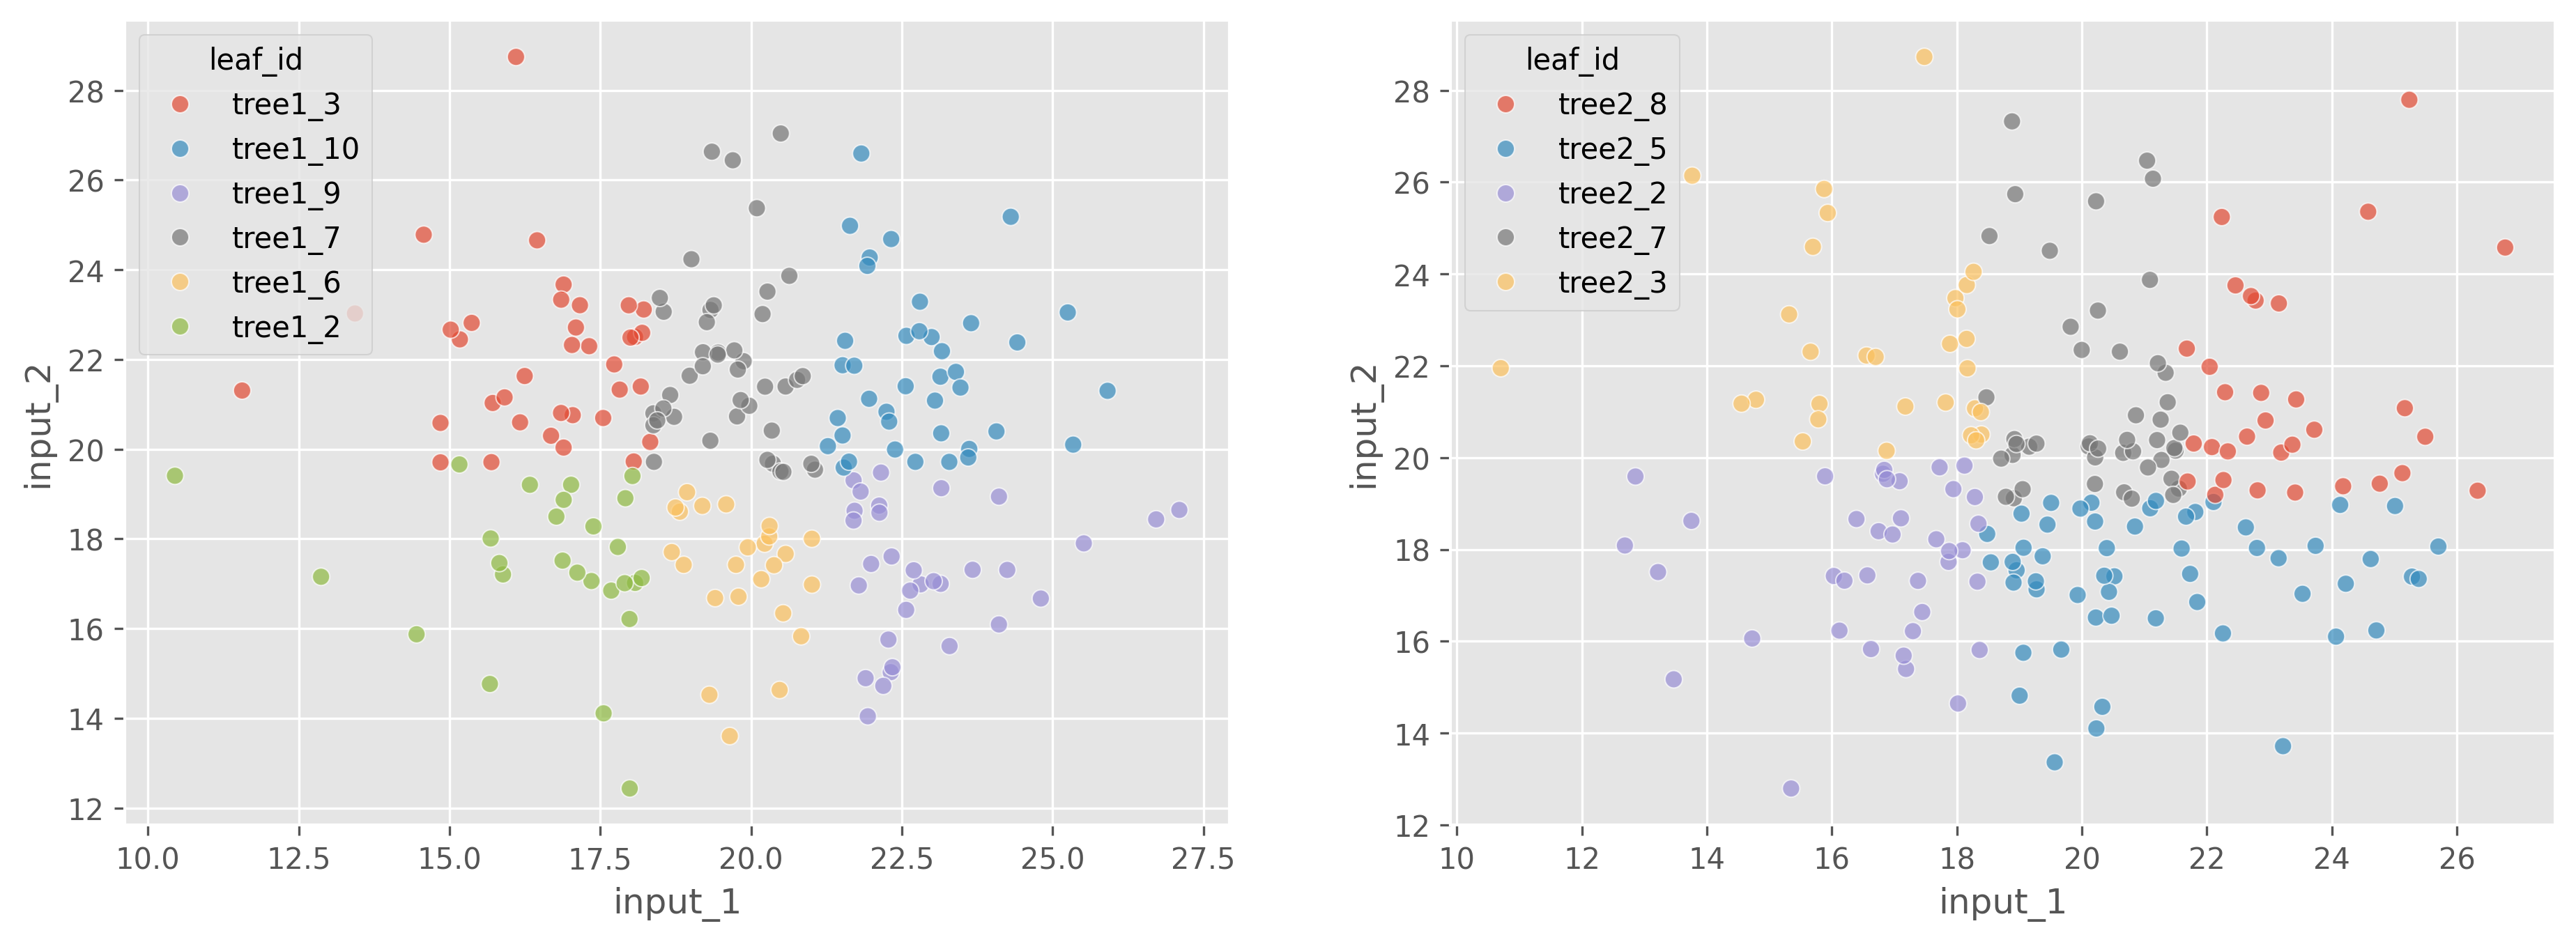

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5), dpi=300)

sns.scatterplot(
    data=df_tree.query("model_id == 1"),
    x="input_1",
    y="input_2",
    alpha =0.7,
    ax=ax[0],
    hue="leaf_id",
)

sns.scatterplot(
    data=df_tree.query("model_id == 2"),
    x="input_1",
    y="input_2",
    alpha =0.7,
    ax=ax[1],
    hue="leaf_id",
)
plt.show()

# 実データ

In [28]:
D_col = "input_employee"
X_cols = [
    'input_capital',
    'input_assets',
    'prefecture_others',
    'prefecture_兵庫県',
    'prefecture_大阪府',
    'prefecture_愛知県',
    'prefecture_東京都',
    'prefecture_神奈川県'
]
Y_cols = ["output_salse", "output_profit"]

gbiz_df = pd.read_csv("https://raw.githubusercontent.com/MasaAsami/ml-dae/refs/heads/main/data/gbizinfo_df_japan2023.csv").dropna(subset=[D_col]).query("input_employee > 0 and input_assets >0 and output_profit > 0")
gbiz_df

,company_id,start_year,name,output_salse,output_profit,input_employee,input_capital,input_assets,years_from_org,prefecture_others,prefecture_兵庫県,prefecture_大阪府,prefecture_愛知県,prefecture_東京都,prefecture_神奈川県
0,1010001000006,2023,五洋建設株式会社,2.450596e+12,6.563000e+10,3114.2,3.044900e+10,1.375992e+11,73.0,0,0,0,0,1,0
1,1010001000708,2023,イチカワ株式会社,5.531100e+10,2.787000e+09,566.4,3.594000e+09,1.753240e+10,NaN,0,0,0,0,1,0
2,1010001003966,2023,スズデン株式会社,2.664722e+11,9.893661e+09,335.6,1.819230e+09,1.739748e+10,71.0,0,0,0,0,1,0
3,1010001008651,2023,ウシオ電機株式会社,2.869900e+11,5.419500e+10,1675.0,1.955600e+10,1.219060e+11,74.0,0,0,0,0,1,0
4,1010001008692,2023,住友商事株式会社,3.643391e+12,9.268130e+11,5137.0,2.199510e+11,1.289993e+12,104.0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2904,9450001002677,2023,株式会社ホーブ,1.333596e+10,3.751500e+08,24.6,4.212500e+08,6.123850e+08,NaN,1,0,0,0,0,0
2906,9470001003062,2023,南海プライウッド株式会社,8.695385e+10,3.853405e+09,417.0,2.121000e+09,1.896820e+10,NaN,1,0,0,0,0,0
2907,9500001002341,2023,セキ株式会社,4.446798e+10,1.324849e+09,291.8,1.201700e+09,1.268480e+10,74.0,1,0,0,0,0,0
2908,9500001014345,2023,大王製紙株式会社,2.209288e+12,7.045500e+10,2548.2,5.179700e+10,1.938842e+11,NaN,1,0,0,0,0,0


In [29]:
dtr1 = DecisionTreeRegressor(max_depth=9, random_state=2025, min_samples_leaf=30) # , min_samples_leaf=30
dtr2 = DecisionTreeRegressor(max_depth=9, random_state=2025, min_samples_leaf=30)

In [30]:
gbiz_df1, gbiz_df2 = train_test_split(gbiz_df,train_size=0.5,random_state=2025)

In [31]:
dtr1.fit(gbiz_df1[X_cols],gbiz_df1[D_col])
dtr2.fit(gbiz_df2[X_cols],gbiz_df2[D_col])

DecisionTreeRegressor(max_depth=9, min_samples_leaf=30, random_state=2025)

In [32]:
gbiz_df_tree = pd.concat(
    [
        gbiz_df2.assign(
            leaf_id = [f"tree1_{_id}" for _id in dtr1.apply(gbiz_df2[X_cols])],
            pred_d = dtr1.predict(gbiz_df2[X_cols]),
            model_id = 1
        ),
        gbiz_df1.assign(
            leaf_id = [f"tree2_{_id}" for _id in dtr2.apply(gbiz_df1[X_cols])],
            pred_d = dtr2.predict(gbiz_df1[X_cols]),
            model_id = 2
        )
    ]
)
gbiz_df_tree

,company_id,start_year,name,output_salse,output_profit,input_employee,input_capital,input_assets,years_from_org,prefecture_others,prefecture_兵庫県,prefecture_大阪府,prefecture_愛知県,prefecture_東京都,prefecture_神奈川県,leaf_id,pred_d,model_id
1851,6140001044373,2023,住友精化株式会社,3.441290e+11,2.117800e+10,1029.8,9.701200e+09,5.815900e+10,NaN,0,1,0,0,0,0,tree1_58,1375.866667,1
327,2010001119497,2023,アジアパイルホールディングス株式会社,7.888000e+09,5.053000e+09,12.8,6.621000e+09,2.841180e+10,NaN,0,0,0,0,1,0,tree1_48,822.729730,1
569,2240001009205,2023,広島ガス株式会社,3.215530e+11,1.578000e+10,681.0,5.224600e+09,4.281180e+10,114.0,1,0,0,0,0,0,tree1_51,1379.034286,1
1570,5430001021815,2023,北海道瓦斯株式会社,6.210050e+11,2.898400e+10,810.2,7.515000e+09,4.903740e+10,112.0,1,0,0,0,0,0,tree1_52,893.688288,1
2015,7010401061336,2023,ＳＷＣＣ株式会社,1.607230e+11,2.164400e+10,330.6,2.422100e+10,3.684720e+10,87.0,0,0,0,0,0,1,tree1_49,642.754839,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,7190001012102,2023,株式会社柿安本店,1.960500e+11,7.158000e+09,916.8,1.269000e+09,1.613160e+10,NaN,1,0,0,0,0,0,tree2_35,629.634286,2
191,1120001041352,2023,因幡電機産業株式会社,1.473625e+12,6.367600e+10,1514.0,1.396200e+10,1.427552e+11,74.0,0,0,1,0,0,0,tree2_52,1897.174359,2
2374,8010701005900,2023,田中商事株式会社,1.715594e+11,4.426383e+09,408.4,1.073200e+09,1.304395e+10,NaN,0,0,0,0,1,0,tree2_30,361.519266,2
1508,5140001070263,2023,古野電気株式会社,3.057080e+11,1.858500e+10,1787.4,7.534000e+09,3.022960e+10,72.0,0,1,0,0,0,0,tree2_41,547.823529,2


In [33]:
count_check = gbiz_df_tree.groupby(["leaf_id"])[[D_col]].count()#.query("target_input > 10")
count_check.tail(30)

,input_employee
leaf_id,
tree1_8,22
tree2_11,38
tree2_12,55
tree2_14,52
tree2_16,46
tree2_17,26
tree2_19,18
tree2_22,29
tree2_24,29


In [34]:
error_corr_result = pd.concat(
    [
        gbiz_df_tree.groupby(["leaf_id"])[[D_col]].count(),
        gbiz_df_tree.groupby("leaf_id").apply(lambda x: (x[[D_col, "pred_d"]].diff(axis=1)["pred_d"]**2).values[0]),
        gbiz_df_tree.groupby("leaf_id").apply(lambda x: x[[D_col, "output_salse"]].corr(method="spearman").values[0][1]),
        gbiz_df_tree.groupby("leaf_id").apply(lambda x: x[[D_col, "output_profit"]].corr(method="spearman").values[0][1]),
        gbiz_df_tree.groupby("leaf_id").apply(lambda x: x[[D_col, "input_capital"]].corr(method="spearman").values[0][1]),
        gbiz_df_tree.groupby("leaf_id").apply(lambda x: x[[D_col, "input_assets"]].corr(method="spearman").values[0][1]),
    ]
    ,axis=1
)

error_corr_result.columns=["cnt", "error_corr", "output_salse_corr", "output_profit_corr", "input_capital_corr", "input_assets_corr"]
error_corr_result.style.bar(color='#ff781c', vmin=0.0, vmax=1.0, subset=["output_salse_corr", "output_profit_corr", "input_capital_corr", "input_assets_corr"])

,cnt,error_corr,output_salse_corr,output_profit_corr,input_capital_corr,input_assets_corr
leaf_id,,,,,,
tree1_10,21,6032.887803,0.531169,0.783117,0.020779,0.188312
tree1_12,24,2644.702044,0.554783,0.543478,-0.208741,-0.120870
tree1_13,38,132469.528595,0.791006,0.139074,0.035781,0.134041
tree1_15,37,13825.056400,0.470867,0.146405,-0.270065,0.117717
tree1_17,28,119.150869,0.710278,0.389216,-0.136855,0.021623
tree1_20,32,11229.162331,0.442082,0.291422,-0.000183,-0.085777
tree1_21,38,1539.777600,0.788817,0.129226,0.228156,0.304081
tree1_22,34,1329.817778,0.727731,-0.109244,-0.130634,-0.143774
tree1_27,40,39552.772268,0.631895,0.285741,-0.088278,0.179737


In [35]:
error_corr_result.mean()

,0
cnt,3.753968e+01
error_corr,3.000865e+06
output_salse_corr,5.385907e-01
output_profit_corr,1.544075e-01
input_capital_corr,9.222082e-02
input_assets_corr,1.227385e-01


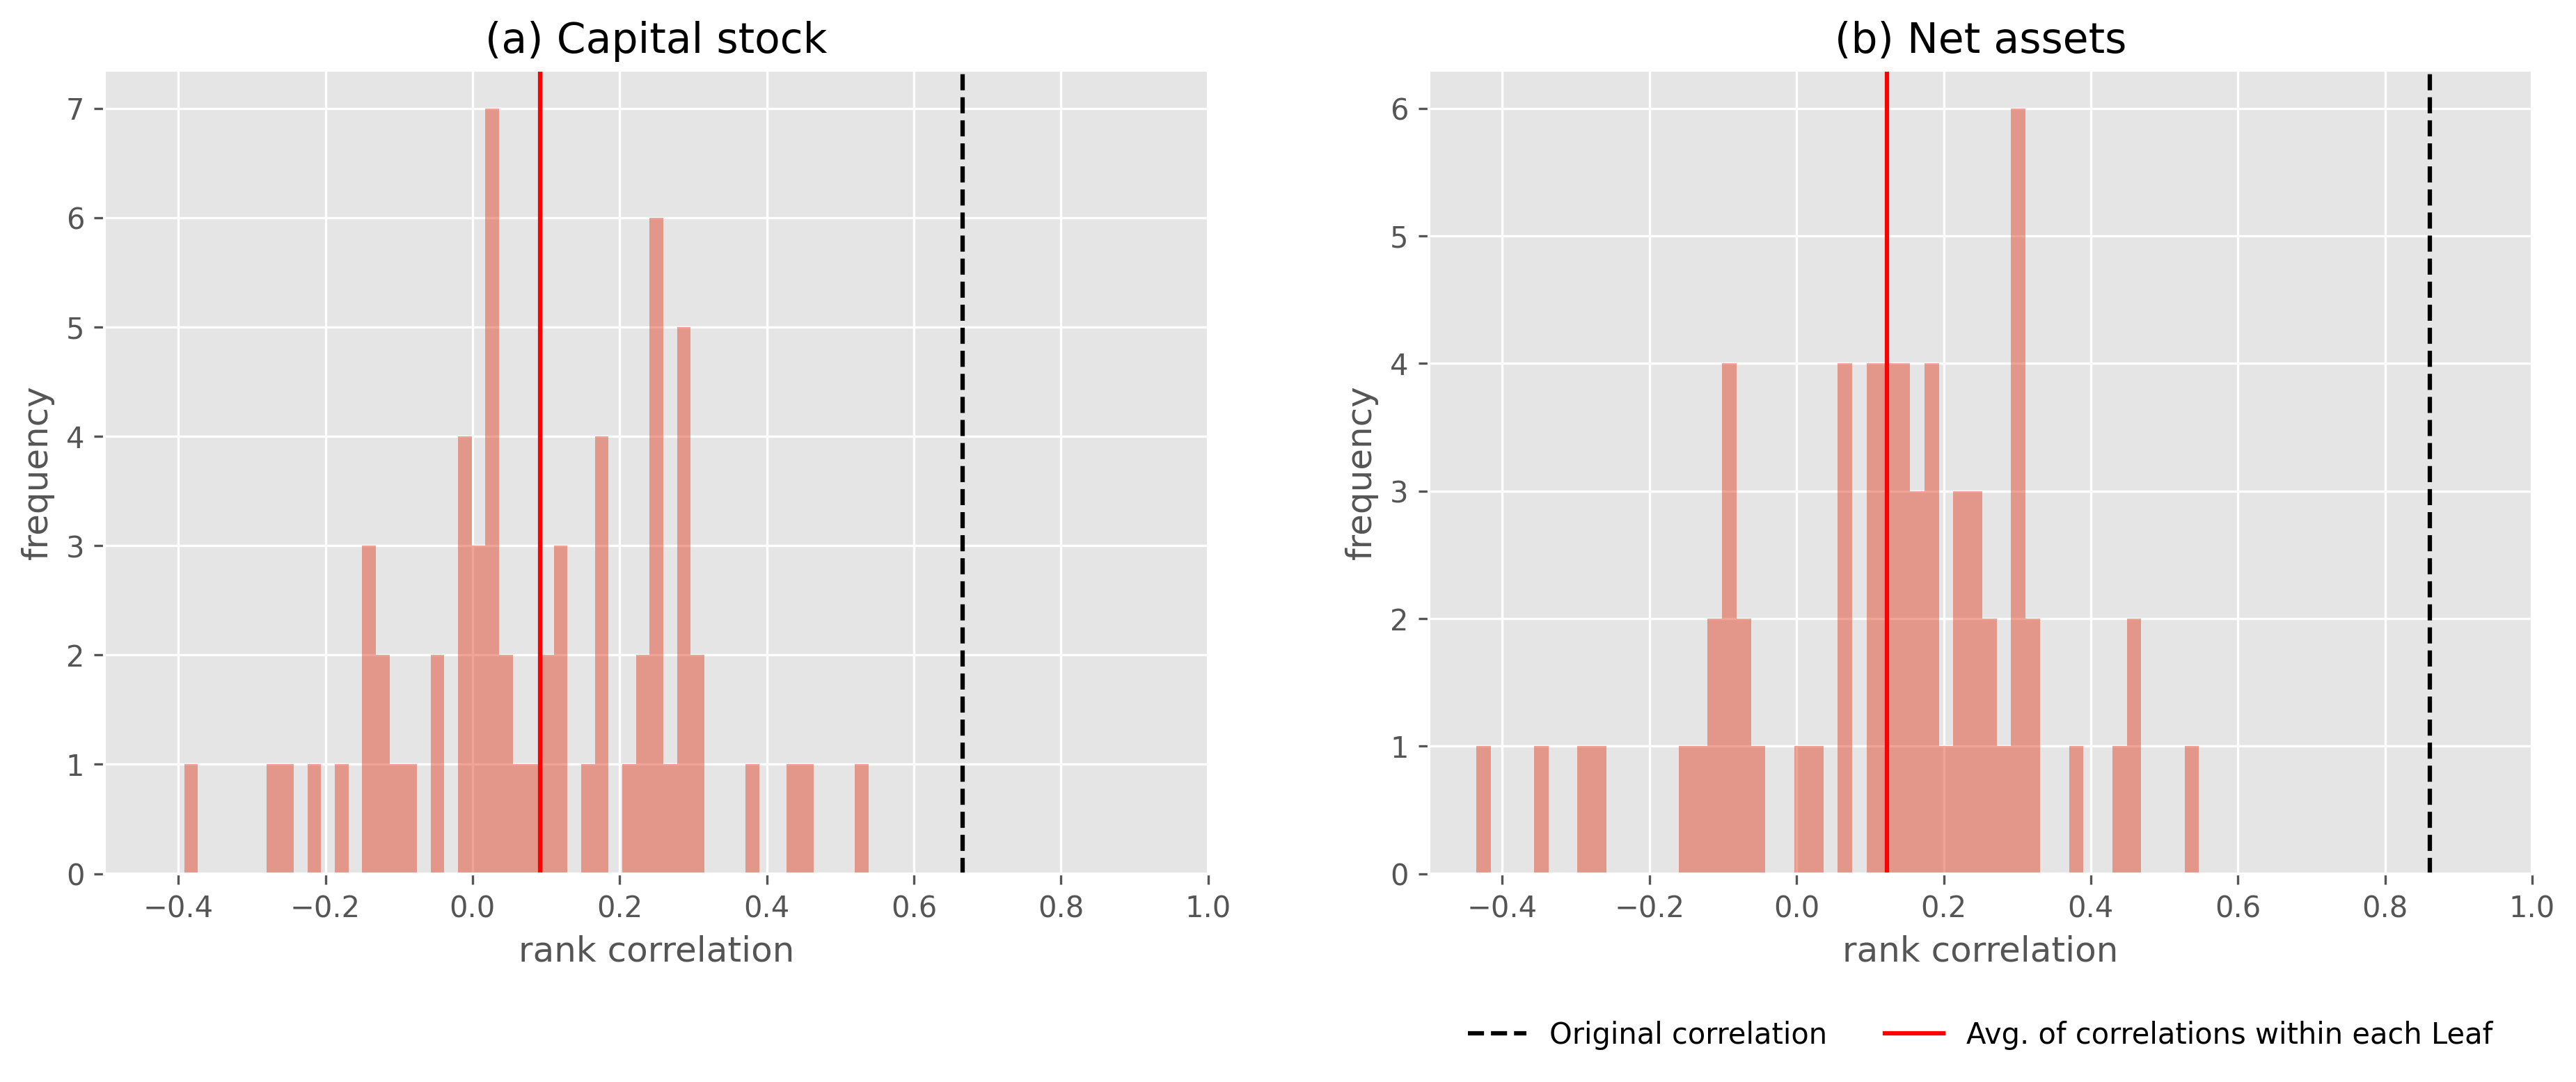

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5), dpi=300)

error_corr_result["input_capital_corr"].hist(bins=50, ax=ax[0], alpha =0.5)
error_corr_result["input_assets_corr"].hist(bins=50, ax=ax[1], alpha =0.5)

ax[0].axvline(gbiz_df_tree[[D_col] + X_cols].corr(method="spearman").loc["input_capital", "input_employee"], color= "black", linestyle="dashed", label="Original correlation")
ax[1].axvline(gbiz_df_tree[[D_col] + X_cols].corr(method="spearman").loc["input_capital", "input_assets"], color= "black", linestyle="dashed", label="Original correlation")

ax[0].axvline(error_corr_result["input_capital_corr"].mean(), color= "red", label="Avg. of correlations within each Leaf")
ax[1].axvline(error_corr_result["input_assets_corr"].mean(), color= "red", label="Avg. of correlations within each Leaf")

ax[0].set_xlabel("rank correlation")
ax[1].set_xlabel("rank correlation")
ax[0].set_ylabel("frequency")
ax[1].set_ylabel("frequency")
ax[0].set_xlim(-0.5, 1)
ax[1].set_xlim(-0.5, 1)
ax[1].legend(framealpha=0, facecolor='1', loc='upper center', bbox_to_anchor=(0.5, -0.15), fancybox=True,  ncol=2)
ax[0].set_title("(a) Capital stock")
ax[1].set_title("(b) Net assets")
plt.show()



In [37]:
def zscore(x,):
    xmean = x.mean()
    xstd  = x.std()
    zscore = (x-xmean)/xstd
    return zscore

dea_df = gbiz_df_tree.copy()
for _col in Y_cols+ [D_col]:
    dea_df[_col] = zscore(dea_df[_col])
    dea_df[_col] += dea_df[_col].min()*-1 + 1

dea_df["retio_1"] = dea_df[Y_cols[0]] / dea_df[D_col]
dea_df["retio_2"] = dea_df[Y_cols[1]] / dea_df[D_col]


retio95_1 = dea_df["retio_1"].quantile(0.99)
retio95_2 = dea_df["retio_2"].quantile(0.99)

dea_df = dea_df.query("retio_1 <= @retio95_1 and retio_2 <= @retio95_2")

sort_leaf_list = dea_df.groupby("leaf_id")[["retio_1", "retio_2"]].mean().sort_values("retio_1").index.to_list()
corr_leaf_list = dea_df.groupby("leaf_id").apply(lambda x: x[["retio_1", "retio_2"]].corr().values[0][1]).sort_values(ascending=True).index.to_list()

In [38]:
random.seed(2025)
leaf_id_list = [sort_leaf_list[0], sort_leaf_list[-1], corr_leaf_list[1]]

In [39]:
efficiency_df_list = []
for _id in leaf_id_list:
    efficiency_df_list.append(
        sim_dea(dea_df, _id, target_input=D_col, output_list=Y_cols)
    )
efficiency_df = pd.concat(efficiency_df_list)

Optimizing DEA: 100%|██████████| 22/22 [00:00<00:00, 79.67it/s]


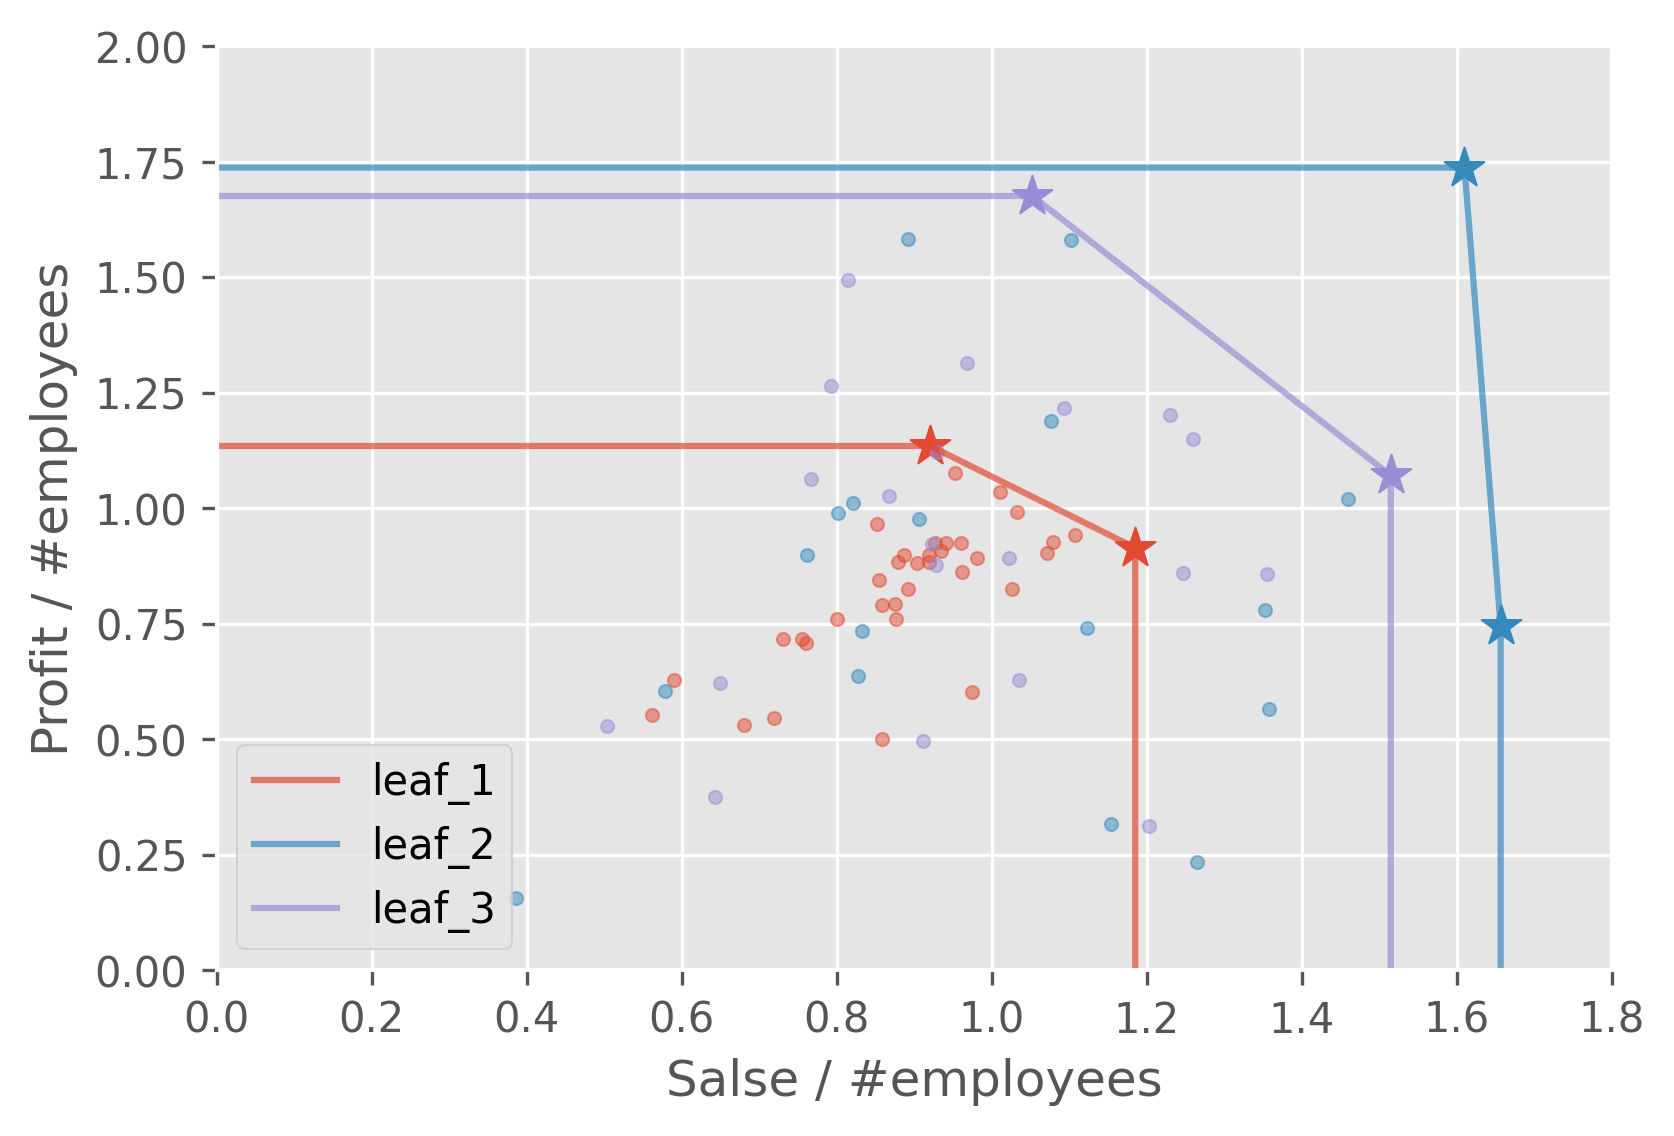

In [40]:
current_palette = sns.color_palette(n_colors=len(leaf_id_list))
fig = plt.figure(figsize=(6, 4), dpi=300)

for i, _id in enumerate(leaf_id_list):
    leaf_name = f"leaf_{i+1}"
    dea_df = efficiency_df.query("leaf_id == @_id")
    subset_efficent = dea_df.query("dea_efficiency > 0.99").sort_values("retio_1", ascending=True)

    fill_x = [0] + subset_efficent["retio_1"].to_list() + [subset_efficent.iloc[-1]["retio_1"]]
    fill_y = [subset_efficent.iloc[0]["retio_2"]] + subset_efficent["retio_2"].to_list() + [0]


    plt.plot(fill_x, fill_y, alpha=.7, color=current_palette[i], label=leaf_name)
    plt.scatter(
        subset_efficent.retio_1,
        subset_efficent.retio_2,
        s=100,
        alpha = 1,
        marker="*",
        c=current_palette[i],
    )
    plt.scatter(
        dea_df.query("dea_efficiency < 0.99").retio_1,
        dea_df.query("dea_efficiency < 0.99").retio_2,
        alpha = .5,
        s=10,
        c=current_palette[i],
        #edgecolors="black",
    )
plt.legend(loc = "lower left")
plt.xlabel(r"")
plt.ylabel(r"")
plt.grid(True)
plt.xlim(0, 1.8)
plt.ylim(0, 2.0)
plt.xlabel(r"Salse / #employees")
plt.ylabel(r"Profit / #employees")
plt.show()

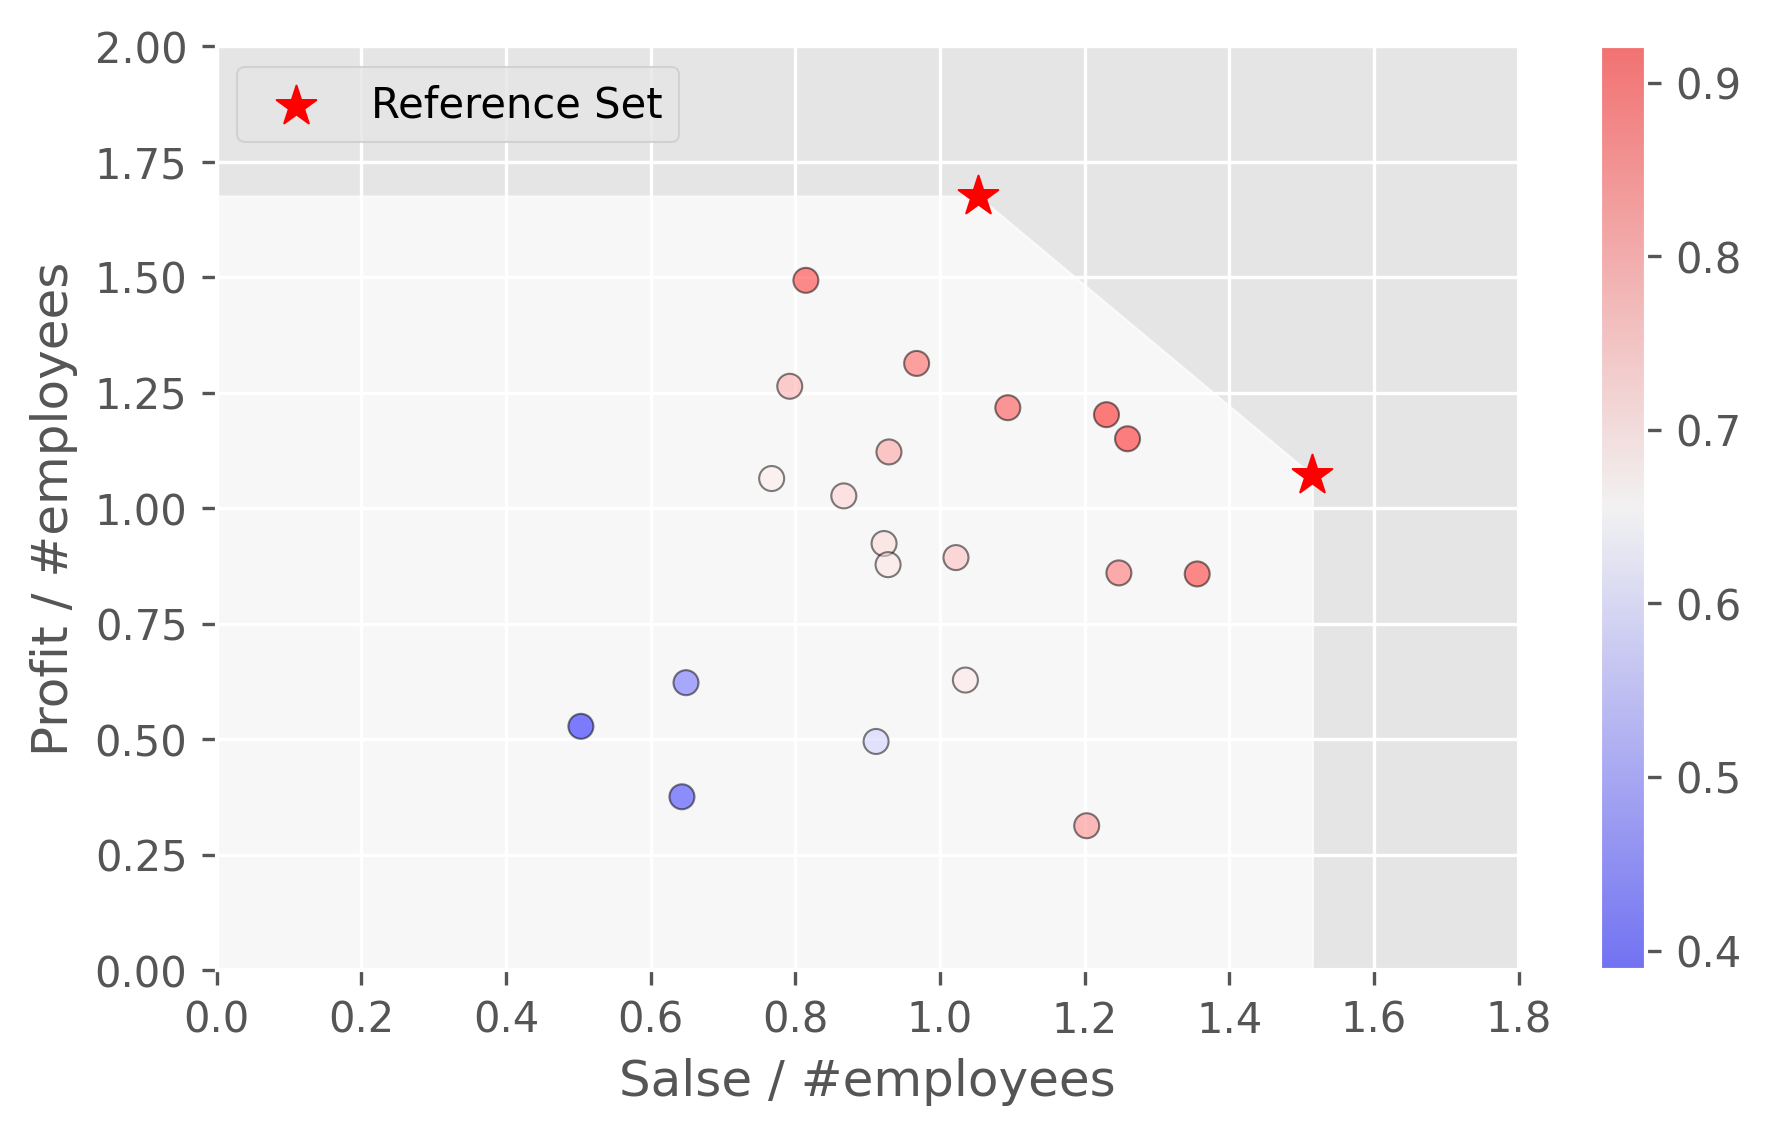

In [41]:
_id = leaf_id_list[-1]
dea_df = efficiency_df.query("leaf_id == @_id")
subset_efficent = dea_df.query("dea_efficiency > 0.99").sort_values("retio_1", ascending=True)
fill_x = [0] + subset_efficent["retio_1"].to_list()
fill_y = [subset_efficent.iloc[0]["retio_2"]] + subset_efficent["retio_2"].to_list()

fig = plt.figure(figsize=(7, 4), dpi=300)
plt.fill_between(fill_x, 0, fill_y, color='w', alpha=.7)
plt.scatter(
    subset_efficent.retio_1,
    subset_efficent.retio_2,
    s=100,
    alpha = 1,
    marker="*",
    c="r",
    label='Reference Set'
)

plt.scatter(
    dea_df.query("dea_efficiency < 0.99").retio_1,
    dea_df.query("dea_efficiency < 0.99").retio_2,
    alpha = .5,
    c = dea_df.query("dea_efficiency < 0.99").dea_efficiency,
    cmap = 'bwr',
    edgecolors="black",
)
cbar = plt.colorbar()


plt.xlabel(r"Salse / #employees")
plt.ylabel(r"Profit / #employees")
plt.grid(True)
plt.xlim(0, 1.8)
plt.ylim(0, 2.0)
plt.legend(loc = "upper left")
plt.show()